Loading data from Student_Performance.csv...
--- Model Training Complete ---
Intercept (B0): -34.0756

Feature Coefficients:
  Hours Studied: 2.8530
  Previous Scores: 1.0184
  Extracurricular Activities: 0.6129
  Sleep Hours: 0.4806
  Sample Question Papers Practiced: 0.1938

R-squared Score: 0.9888


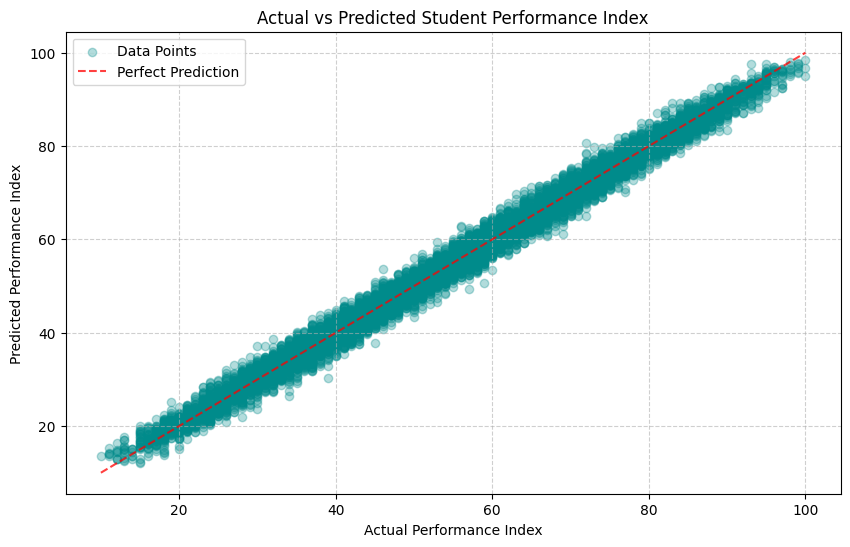

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class MultipleLinearRegression:
    """
    A class to perform Multiple Linear Regression (y = B0 + B1*x1 + B2*x2 + ...)
    using the Normal Equation method.
    """

    def __init__(self):
        self.coefficients = None
        self.intercept = None

    def fit(self, X, y):
        """
        Calculates coefficients using the Normal Equation:
        B = (X^T * X)^-1 * X^T * y
        """
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)

        # Add a column of ones to X for the intercept (B0)
        num_samples = X.shape[0]
        X_b = np.c_[np.ones((num_samples, 1)), X]

        try:
            # Normal Equation: (X^T * X)^-1 * X^T * y
            theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

            self.intercept = theta_best[0][0]
            self.coefficients = theta_best[1:].flatten()

            print(f"--- Model Training Complete ---")
            print(f"Intercept (B0): {self.intercept:.4f}")
        except np.linalg.LinAlgError:
            print("Error: The matrix is singular. Check for redundant features.")

    def predict(self, X):
        X = np.array(X)
        return X.dot(self.coefficients) + self.intercept

    def r_squared(self, X, y):
        y = np.array(y).flatten()
        y_pred = self.predict(X).flatten()
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

def prepare_student_data(file_path):
    """
    Loads and preprocesses the Student Performance dataset.
    """
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(r"C:\Users\NITRO V\Downloads\DAV exps\Student_Performance.csv")

    # 1. Handle Categorical Data: Convert 'Extracurricular Activities' to 0/1
    # 'Yes' -> 1, 'No' -> 0
    df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

    # 2. Define Features and Target
    # Features: Hours Studied, Previous Scores, Extracurricular Activities, Sleep Hours, Question Papers
    X_cols = [
        'Hours Studied',
        'Previous Scores',
        'Extracurricular Activities',
        'Sleep Hours',
        'Sample Question Papers Practiced'
    ]
    y_col = 'Performance Index'

    # Drop rows with missing values
    df = df.dropna(subset=X_cols + [y_col])

    return df[X_cols].values, df[y_col].values, X_cols

# --- Execution Section ---

if __name__ == "__main__":
    FILE_NAME = "Student_Performance.csv"

    try:
        # 1. Load and Preprocess
        X, y, feature_names = prepare_student_data(FILE_NAME)

        # 2. Train Model
        model = MultipleLinearRegression()
        model.fit(X, y)

        # 3. Print Feature Importance
        print("\nFeature Coefficients:")
        for name, coef in zip(feature_names, model.coefficients):
            print(f"  {name}: {coef:.4f}")

        # 4. Evaluate
        r2 = model.r_squared(X, y)
        print(f"\nR-squared Score: {r2:.4f}")

        # 5. Visualization: Predicted vs Actual
        y_pred = model.predict(X)
        plt.figure(figsize=(10, 6))
        plt.scatter(y, y_pred, color='darkcyan', alpha=0.3, label='Data Points')

        # Diagonal line representing perfect prediction
        lims = [np.min([y.min(), y_pred.min()]), np.max([y.max(), y_pred.max()])]
        plt.plot(lims, lims, 'r--', alpha=0.75, zorder=3, label='Perfect Prediction')

        plt.title('Actual vs Predicted Student Performance Index')
        plt.xlabel('Actual Performance Index')
        plt.ylabel('Predicted Performance Index')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    except FileNotFoundError:
        print(f"Error: {FILE_NAME} not found. Please ensure the file is in the same directory.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")